# 06 — The lab-frame halo: what the Earth's motion does to the rates

**Paper element.** Supplemental Material, The Halo Model: the change of
velocity-distribution convention adopted for the current pass, and the two
places it enters the rate calculation with opposite sign.

**What this notebook is.** Everything up to and including the v9.1 release used
the Standard Halo Model in the **Galactic rest frame** — a truncated Maxwellian
in the frame the halo is at rest in, with $v_0$ = 220 km/s and
$v_\text{esc}$ = 544 km/s. The two levitated-sensor searches this analysis
overlays — Monteiro *et al.* 2020 ([arXiv:2007.12067](https://arxiv.org/abs/2007.12067))
and Tseng *et al.* 2025 ([arXiv:2508.00815](https://arxiv.org/abs/2508.00815)) —
both use the **lab-frame** form of Lewin & Smith (1996): the same isotropic
Maxwellian, boosted into the detector frame by the Earth's motion through the
halo and integrated over arrival direction. We are adopting that form.
$v_0$ and $v_\text{esc}$ do not change; what changes is that the observer moves,
at $v_E$ = 245 km/s.

This notebook is about **rates and the mechanism**, not about limit contours.
The question it answers is: *why does the same change make one number go up by
1.37 and another go down by 0.70?*

The short answer, which the rest of the notebook makes quantitative:

* Boosting into the lab frame **speeds the halo up**, so anything that counts
  particles crossing a **fixed aperture** — the flux cut $m_\text{cut}$, and the
  transit counts and rates of a **short-range** mediator, whose reach is set by
  $\lambda$ and barely depends on speed — sees $\langle v\rangle$ and goes
  **up** by 1.375.
* But the Coulomb reach of a *threshold* kick is $b_\text{max} \propto 1/v$, so
  the area a threshold-crossing flyby must land in goes as $1/v^2$. Anything
  that counts **threshold-reaching** encounters through a **massless** mediator
  sees $\langle 1/v\rangle$ and goes **down** by 0.703.

Both are moments of the *same* distribution. They move in opposite directions
because a faster particle is easier to *meet* and harder to be *kicked hard by*.
Every rate in this analysis sits somewhere in the bracket
$[\,\langle 1/v\rangle,\ \langle v\rangle\,] = [0.703,\ 1.375]$, and where it
sits is decided by how the reach depends on speed — i.e. by the mediator range.
The one exception is the region near the coupling floor, which falls *below* the
bracket, and §6 explains why.

**Sections**

1. [The convention, and how one process evaluates both frames](#1)
2. [The two distributions](#2)
3. [The two moments, and why they pull opposite ways](#3)
4. [Verification against the shipped halo shards](#4)
5. [$dR/dq$: the shape change, not just the normalisation](#5)
6. [The expected count $\mu$ in the analysis window](#6)
7. [The kinematic wall](#7)
8. [Summary](#8)

Every number quoted in the prose below is computed in a cell, and the
load-bearing ones carry asserts. Nothing here is read back from a limit surface;
the only released products used are the **projection kernel** (through
`Release.make_xsec`, never `luhdm.rate.make_xsec` — see notebook 02 §"The
projection kernel") and the **halo diagnostic shards** of the two builds, used in
§4 purely as an independent check on moments computed here from scratch.

In [1]:
%matplotlib inline
import os
os.environ.setdefault("TQDM_DISABLE", "1")   # keep tabulation bars out of outputs

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import config, cross_section, efficiency, halo, limits, rate, units
from luhdm import release

# ---- the convention under study --------------------------------------------
V_E_KMS = 245.0                  # Monteiro 2020 / Tseng 2025 / Lewin & Smith
KMS = units.C_M_S / 1e3          # natural units (c = 1) -> km/s

# ---- fiducials, all from config so this notebook cannot drift from the scan --
Q_THRESH = config.Q_THRESH       # 1 TeV/c analysis threshold
T_TOTAL = config.T_EXPOSURE      # night-selection live-time, 219.66 h
R_eff = config.R_EFF             # 260 um
V0_KMS = config.V0 * KMS
VESC_KMS = config.VESC * KMS

# The release file supplies exactly one thing here: the projection kernel (and
# the impact-parameter cap) that every cross-section handle below is built with.
# File B is the bare-halo, f_DM = 0.1 hypothesis -- the right companion for a
# frame comparison, which is about the halo and not about the overburden.
REL_PATH = Path(os.environ.get("LUHDM_RELEASE_B",
                "../release/luhdm_datarelease_v10_B_f0p1_noatm.h5"))
rel = release.open_release(REL_PATH)

# figure conventions: the incoming convention is the saturated blue, the
# historical one the muted green dashed -- the same pairing notebook 02 uses for
# "this release" vs "the historical default". Red stays reserved for edges.
C_LAB = plt.cm.viridis(0.10)
C_REST = plt.cm.viridis(0.68)
C_EDGE = "#d62728"

for _d in ("png", "svg", "pdf"):
    os.makedirs(_d, exist_ok=True)


def save_figure(fig, name, **kw):
    # same helper as notebooks 02-05: png/, svg/ and pdf/, stamped with the
    # release whose conventions the figure was built under
    fig.text(0.995, 0.004, f"POLONAISE UHDM data release {rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)


print(f"v0 = {V0_KMS:.0f} km/s   v_esc = {VESC_KMS:.0f} km/s   "
      f"v_E = {V_E_KMS:.0f} km/s")
print(f"q_th = {Q_THRESH:.0f} GeV/c   T = {T_TOTAL / 3600:.2f} h   "
      f"R_eff = {R_eff * 1e6:.0f} um")
print(f"cube: {REL_PATH.name}  kernel = {rel.projection_kernel}  "
      f"v_earth_km_s = {rel.v_earth_km_s:g} "
      f"({'lab' if rel.v_earth_km_s else 'rest'} frame)")

v0 = 220 km/s   v_esc = 544 km/s   v_E = 245 km/s
q_th = 1000 GeV/c   T = 219.66 h   R_eff = 260 um
cube: luhdm_datarelease_v10_B_f0p1_noatm.h5  kernel = isotropic-folded  v_earth_km_s = 245 (lab frame)


<a id="1"></a>
## 1. The convention, and how one process evaluates both frames

The lab-frame distribution is the isotropic truncated Maxwellian boosted by
$v_E$ and integrated over arrival direction (Lewin & Smith 1996, Eq. 3.11; the
form written out in `luhdm/halo.py`):

$$f(v) \;=\; \frac{\pi v_0^2}{N_0\,v_E}\; v \left[\,
e^{-(v-v_E)^2/v_0^2} \;-\; e^{-w_+^2/v_0^2}\right],
\qquad w_+ = \min(v + v_E,\; v_\text{esc}),$$

zero above $v_\text{esc} + v_E$, with
$N_0 = (\pi v_0^2)^{3/2}\big[\mathrm{erf}(x) - \tfrac{2}{\sqrt\pi}x e^{-x^2}\big]$,
$x = v_\text{esc}/v_0$. Setting $v_E \to 0$ recovers the rest-frame truncated
Maxwellian exactly — the expression is $0/0$ there, so `halo.standard_halo_model`
dispatches $v_E = 0$ to the historical code path rather than approaching it
numerically, and the default pipeline is bit-identical to what it always was.

### The convention is two settings, not one

In the code the frame is a **recorded convention**, read once at import from the
environment variable `LUHDM_V_EARTH` (km/s, default 0):

* `config.V_E` — the boost, which sets the *shape* of $f(v)$;
* `config.V_MAX = VESC + V_E` — the *ceiling of every speed integral* in
  `luhdm.rate`. In the lab frame a particle sitting at the Galactic escape speed
  and met head-on arrives at $v_\text{esc} + v_E$, so stopping a speed grid at
  $v_\text{esc}$ would silently truncate exactly the new tail.

These two must never move apart, which is why `config.set_v_earth_km_s()` exists
and sets both together; `scripts/build_release.py` calls it from its `--v-earth`
handling. This notebook uses that one setter inside a context manager, so
(a) the frame is never half-changed, (b) the global is restored on exit, and
(c) the $f(v)$ handed to `luhdm.rate` is built with the *same* $v_E$ explicitly,
so the shape and the ceiling cannot disagree. Nothing outside a `with` block ever
sees a modified global — asserted below.

In [2]:
class halo_frame:
    """Evaluate one halo frame: set (V_E, V_MAX) together, restore on exit.

    Yields the f(v) callable for that frame, built with an EXPLICIT v_E rather
    than relying on the global, so the distribution passed into luhdm.rate and
    the speed ceiling luhdm.rate integrates to are guaranteed to be the same
    convention. Returning the callable is the point: every rate call below takes
    its f(v) from the with-statement, so there is no way to pair one frame's
    distribution with the other frame's grid.
    """

    def __init__(self, v_e_km_s):
        self.v_e_km_s = float(v_e_km_s)

    def __enter__(self):
        self._saved = config.V_E * config.C / 1e3
        v_e = config.set_v_earth_km_s(self.v_e_km_s)
        assert config.V_MAX == config.VESC + v_e
        return lambda v: halo.standard_halo_model(v, v_E=v_e)

    def __exit__(self, *exc):
        config.set_v_earth_km_s(self._saved)
        return False


# the import-time state of this process: the default, i.e. the Galactic rest frame
print(f"at import: config.V_E = {config.V_E:g}  ->  "
      f"{config.V_E * KMS:.0f} km/s   V_MAX = {config.V_MAX * KMS:.0f} km/s")
assert config.V_E == 0.0, "this notebook must be launched WITHOUT LUHDM_V_EARTH set"

with halo_frame(V_E_KMS) as f_lab:
    print(f"inside a lab-frame block: V_E = {config.V_E * KMS:.0f} km/s   "
          f"V_MAX = {config.V_MAX * KMS:.0f} km/s")
    assert abs(config.V_MAX * KMS - (VESC_KMS + V_E_KMS)) < 1e-9

print(f"after the block:          V_E = {config.V_E * KMS:.0f} km/s   "
      f"V_MAX = {config.V_MAX * KMS:.0f} km/s")
assert config.V_E == 0.0 and config.V_MAX == config.VESC

# v_E = 0 must be the historical function, not a numerical approach to it
_vchk = np.linspace(1e-9, config.VESC * 0.999999, 5000)
assert np.array_equal(halo.standard_halo_model(_vchk, v_E=0.0),
                      halo._shm_galactic_rest_frame(_vchk)), \
    "the v_E = 0 branch is no longer bit-identical to the historical SHM"
print("v_E = 0 reproduces the historical SHM bit for bit")

V_MAX_REST = config.VESC
V_MAX_LAB = config.VESC + V_E_KMS * 1e3 / config.C
print(f"\nsupport: rest frame [0, {V_MAX_REST * KMS:.0f}] km/s,  "
      f"lab frame [0, {V_MAX_LAB * KMS:.0f}] km/s")

at import: config.V_E = 0  ->  0 km/s   V_MAX = 544 km/s
inside a lab-frame block: V_E = 245 km/s   V_MAX = 789 km/s
after the block:          V_E = 0 km/s   V_MAX = 544 km/s
v_E = 0 reproduces the historical SHM bit for bit

support: rest frame [0, 544] km/s,  lab frame [0, 789] km/s


<a id="2"></a>
## 2. The two distributions

The boost does two things at once, and they are easiest to see separately:

* **The slow tail is drained.** In the rest frame a dark-matter particle can be
  nearly at rest with respect to the sensor. In the lab frame it cannot: to
  arrive slowly it has to be moving *with* the Earth at almost exactly 245 km/s,
  which is a small slice of the sphere of arrival directions. The distribution
  is pushed away from $v = 0$ and its peak moves from $v_0$ to roughly
  $\sqrt{v_0^2 + \ldots}$ — computed below rather than approximated.
* **A new fast tail appears** between $v_\text{esc}$ and $v_\text{esc} + v_E$,
  populated by particles the Earth runs into head-on. This is the part of the
  distribution the old convention did not have at all.

Both matter, and — this is the point of the whole notebook — they matter to
*different observables*.

In [3]:
# The two distributions on a common grid running to the LAB support edge, so
# the rest-frame curve's hard stop at v_esc is visible as a stop and not as the
# end of the plot.
NV = 2_000_001                      # fine linear grid: the moments below are
V = np.linspace(V_MAX_LAB * 1e-9, V_MAX_LAB, NV)   # quadrature, not sampling
with halo_frame(0.0) as f_rest_fn:
    F_REST = f_rest_fn(V)
with halo_frame(V_E_KMS) as f_lab_fn:
    F_LAB = f_lab_fn(V)

# A decimated view of the same arrays, for DRAWING only. The quadrature above
# needs 2e6 points; a vector figure containing 2e6 line vertices does not, and
# would be a 200 MB svg.
DEC = slice(None, None, max(1, NV // 1500))
VD, FD_REST, FD_LAB = V[DEC], F_REST[DEC], F_LAB[DEC]

NORM_REST = float(np.trapezoid(F_REST, V))
NORM_LAB = float(np.trapezoid(F_LAB, V))
print(f"normalisation   rest {NORM_REST:.8f}   lab {NORM_LAB:.8f}")
assert abs(NORM_REST - 1) < 1e-6 and abs(NORM_LAB - 1) < 1e-6, \
    "one of the two speed distributions is not normalised on its own support"

# where the new tail is, in probability and in FLUX (the f(v) v weighting that
# an aperture actually sees)
above = V > config.VESC
P_ABOVE = float(np.trapezoid(F_LAB[above], V[above]))
FLUX_ABOVE = float(np.trapezoid((F_LAB * V)[above], V[above])
                   / np.trapezoid(F_LAB * V, V))
print(f"lab frame above the old {VESC_KMS:.0f} km/s ceiling: "
      f"{P_ABOVE:.2%} of the probability, {FLUX_ABOVE:.2%} of the flux")
assert F_LAB[-1] == 0.0 or F_LAB[-1] < 1e-6 * F_LAB.max(), \
    "the lab distribution does not close at v_esc + v_E"

# and where the slow tail went
for thr_kms in (100.0, 150.0, 200.0):
    t = thr_kms * 1e3 / config.C
    m = V < t
    p_r = float(np.trapezoid(F_REST[m], V[m]))
    p_l = float(np.trapezoid(F_LAB[m], V[m]))
    print(f"  P(v < {thr_kms:3.0f} km/s):  rest {p_r:6.2%}   lab {p_l:6.2%}   "
          f"(x{p_l / p_r:.2f})")

V_PEAK_REST = float(V[int(np.argmax(F_REST))]) * KMS
V_PEAK_LAB = float(V[int(np.argmax(F_LAB))]) * KMS
print(f"\npeak of f(v):   rest {V_PEAK_REST:.0f} km/s (= v0)   "
      f"lab {V_PEAK_LAB:.0f} km/s")

normalisation   rest 0.99999999   lab 1.00000000
lab frame above the old 544 km/s ceiling: 6.31% of the probability, 11.22% of the flux
  P(v < 100 km/s):  rest  6.29%   lab  2.01%   (x0.32)
  P(v < 150 km/s):  rest 18.30%   lab  6.54%   (x0.36)
  P(v < 200 km/s):  rest 35.49%   lab 14.63%   (x0.41)

peak of f(v):   rest 220 km/s (= v0)   lab 320 km/s


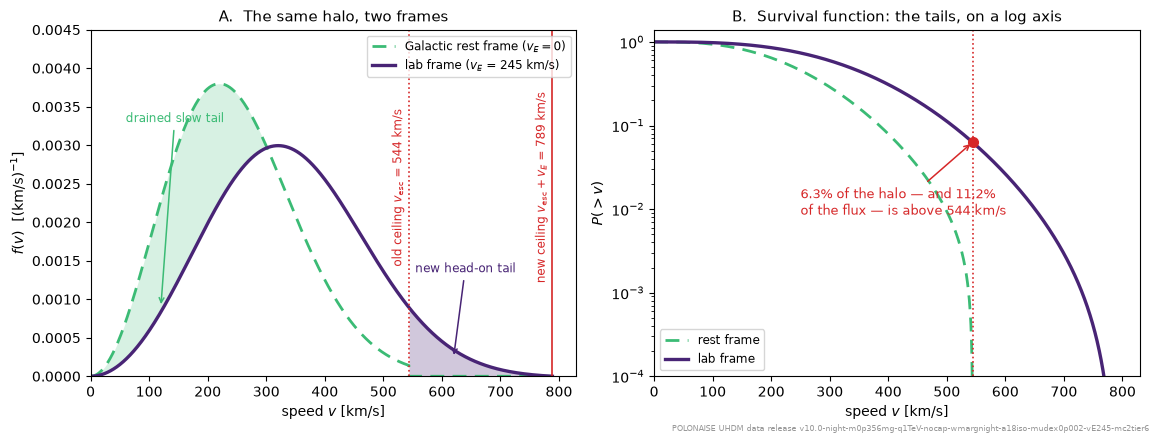

In [4]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.6, 4.4))

# --- A: the distributions themselves -----------------------------------------
axA.plot(VD * KMS, FD_REST / KMS, color=C_REST, lw=2.0, ls=(0, (5, 3)),
         label=r"Galactic rest frame ($v_E = 0$)")
axA.plot(VD * KMS, FD_LAB / KMS, color=C_LAB, lw=2.4,
         label=rf"lab frame ($v_E$ = {V_E_KMS:.0f} km/s)")
axA.fill_between(VD * KMS, 0,
                 np.where(VD > config.VESC, FD_LAB, 0.0) / KMS,
                 color=C_LAB, alpha=0.25, lw=0)
axA.fill_between(VD * KMS, np.minimum(FD_REST, FD_LAB) / KMS, FD_REST / KMS,
                 where=FD_REST > FD_LAB, color=C_REST, alpha=0.20, lw=0)
axA.axvline(VESC_KMS, color=C_EDGE, lw=1.2, ls=":")
axA.text(VESC_KMS - 8, 0.55, r"old ceiling $v_{\rm esc}$ = 544 km/s ",
         color=C_EDGE, fontsize=8.5, rotation=90, ha="right", va="center",
         transform=axA.get_xaxis_transform())
axA.axvline(V_MAX_LAB * KMS, color=C_EDGE, lw=1.2, ls="-")
axA.text(V_MAX_LAB * KMS - 8, 0.55,
         rf"new ceiling $v_{{\rm esc}}+v_E$ = {V_MAX_LAB * KMS:.0f} km/s ",
         color=C_EDGE, fontsize=8.5, rotation=90, ha="right", va="center",
         transform=axA.get_xaxis_transform())
axA.annotate("drained slow tail", xy=(120, 0.9e-3), xytext=(60, 3.3e-3),
             fontsize=8.5, color=C_REST,
             arrowprops=dict(arrowstyle="->", color=C_REST, lw=1.1))
axA.annotate("new head-on tail", xy=(620, 2.4e-4), xytext=(640, 1.35e-3),
             fontsize=8.5, color=C_LAB, ha="center",
             arrowprops=dict(arrowstyle="->", color=C_LAB, lw=1.1))
axA.set_ylim(0, 4.5e-3)
axA.set_xlim(0, 830)
axA.set_xlabel(r"speed $v$ [km/s]")
axA.set_ylabel(r"$f(v)$  [(km/s)$^{-1}$]")
axA.set_title("A.  The same halo, two frames", fontsize=11)
axA.legend(fontsize=8.5, loc="upper right")

# --- B: the cumulative, which is where "how much sits above 544" is read off --
cdf = lambda f, v: np.concatenate([[0.0], np.cumsum(
    0.5 * (f[1:] + f[:-1]) * np.diff(v))])
CDF_REST, CDF_LAB = cdf(FD_REST, VD), cdf(FD_LAB, VD)
axB.plot(VD * KMS, 1 - CDF_REST, color=C_REST, lw=2.0, ls=(0, (5, 3)),
         label="rest frame")
axB.plot(VD * KMS, 1 - CDF_LAB, color=C_LAB, lw=2.4, label="lab frame")
axB.axvline(VESC_KMS, color=C_EDGE, lw=1.2, ls=":")
axB.plot([VESC_KMS], [P_ABOVE], "o", ms=7, color=C_EDGE, zorder=5)
axB.annotate(f"{P_ABOVE:.1%} of the halo — and {FLUX_ABOVE:.1%}\n"
             f"of the flux — is above 544 km/s",
             xy=(VESC_KMS, P_ABOVE), xytext=(250, 0.012), fontsize=9,
             color=C_EDGE, ha="left", va="center",
             arrowprops=dict(arrowstyle="->", color=C_EDGE, lw=1.1))
axB.set_yscale("log")
axB.set_ylim(1e-4, 1.4)
axB.set_xlim(0, 830)
axB.set_xlabel(r"speed $v$ [km/s]")
axB.set_ylabel(r"$P(> v)$")
axB.set_title("B.  Survival function: the tails, on a log axis", fontsize=11)
axB.legend(fontsize=8.5, loc="lower left")

fig.tight_layout()
save_figure(fig, "06_speed_distributions")
plt.show()

<a id="3"></a>
## 3. The two moments, and why they pull opposite ways

Almost everything the frame change does to this analysis is carried by two
numbers. Both are moments of $f(v)$; they move in opposite directions.

### $\langle v\rangle$: what a fixed aperture sees

A particle crossing a *fixed* area $A$ contributes to the flux in proportion to
its speed: $N = n\,\langle v\rangle\,A\,T$. Faster halo, more crossings. This is
the moment behind the release's flux cut

$$m_\text{cut} \;=\; \frac{f_\text{DM}\,\rho_0\,\langle v\rangle\,T_\text{obs}\,
\pi b_\text{cap}^2}{N_\text{req}},$$

the largest DM mass for which the halo still delivers $N_\text{req}$ = 3
particles through the $b_\text{cap}$ = 10 cm hardware aperture during the
exposure (notebook 05 §4). $m_\text{cut} \propto \langle v\rangle$ exactly, so
the right-hand edge of every excluded region moves out by the
$\langle v\rangle$ ratio.

### $\langle 1/v\rangle$: what a threshold reach sees

A *threshold* encounter is different. For a massless (Coulomb) mediator the
impulse delivered at impact parameter $b$ is $\Delta p = 2\alpha/(bv)$, so the
reach that still delivers $q_\text{th}$ is

$$b_\text{max}(v) \;=\; \frac{2\alpha}{q_\text{th}\,v} \;\propto\; \frac1v ,$$

and the target area is $\pi b_\text{max}^2 \propto 1/v^2$. The transit count
therefore carries

$$N_t \;\propto\; \int f(v)\,v\cdot \frac{1}{v^2}\,dv \;=\; \Big\langle \frac1v \Big\rangle .$$

One power of $v$ from the flux, two against it from the shrinking target: net
$1/v$. **A faster particle is easier to meet and harder to be kicked hard by,**
and the second effect wins by one power.

The two limits bracket everything in between: a *short-range* mediator has a
reach fixed at roughly $\lambda$ regardless of speed, so it is a fixed aperture
and scales as $\langle v\rangle$; a *massless* one is pure Coulomb and scales as
$\langle 1/v\rangle$. §4 shows the shipped shards interpolating between exactly
those two numbers.

In [5]:
def moment(f, v, p):
    """<v^p> under a normalised speed distribution, by trapezoid on v."""
    return float(np.trapezoid(f * v ** p, v) / np.trapezoid(f, v))


V_MEAN_REST = moment(F_REST, V, 1)
V_MEAN_LAB = moment(F_LAB, V, 1)
INV_REST = moment(F_REST, V, -1)
INV_LAB = moment(F_LAB, V, -1)

R_VMEAN = V_MEAN_LAB / V_MEAN_REST
R_INV = INV_LAB / INV_REST

INV2_REST = moment(F_REST, V, -2)
INV2_LAB = moment(F_LAB, V, -2)

# Printed as the moments themselves, so the "lab / rest" column always has the
# same sign as the quantity in the row. (Quoting 1/<1/v> as a speed is nice for
# intuition -- it rises, 194 -> 276 km/s -- but its ratio is 1/0.703, which is
# exactly the sign confusion this notebook is trying to remove.)
print(f"{'moment':<26}{'rest frame':>15}{'lab frame':>15}{'lab / rest':>13}")
print("-" * 69)
print(f"{'<v>          [km/s]':<26}{V_MEAN_REST * KMS:>15.2f}"
      f"{V_MEAN_LAB * KMS:>15.2f}{R_VMEAN:>13.4f}")
print(f"{'<1/v>     [s/km, x1e3]':<26}{INV_REST / KMS * 1e3:>15.4f}"
      f"{INV_LAB / KMS * 1e3:>15.4f}{R_INV:>13.4f}")
print(f"{'<1/v^2>  [s2/km2, x1e6]':<26}{INV2_REST / KMS ** 2 * 1e6:>15.4f}"
      f"{INV2_LAB / KMS ** 2 * 1e6:>15.4f}{INV2_LAB / INV2_REST:>13.4f}")
print(f"\nas speeds, for intuition:  <v> = {V_MEAN_REST * KMS:.1f} -> "
      f"{V_MEAN_LAB * KMS:.1f} km/s,   "
      f"1/<1/v> = {KMS / INV_REST:.1f} -> {KMS / INV_LAB:.1f} km/s")

assert abs(V_MEAN_REST * KMS - 245.97) < 0.02, "<v> rest frame moved"
assert abs(V_MEAN_LAB * KMS - 338.17) < 0.02, "<v> lab frame moved"
assert abs(R_VMEAN - 1.375) < 0.002, "the <v> ratio is not 1.375"
assert abs(R_INV - 0.703) < 0.002, "the <1/v> ratio is not 0.703"
print(f"\nthe two ratios pull opposite ways: x{R_VMEAN:.3f} against "
      f"x{R_INV:.3f}   (product {R_VMEAN * R_INV:.3f})")

moment                         rest frame      lab frame   lab / rest
---------------------------------------------------------------------
<v>          [km/s]                245.97         338.17       1.3748
<1/v>     [s/km, x1e3]             5.1519         3.6238       0.7034
<1/v^2>  [s2/km2, x1e6]           41.5789        19.5522       0.4702

as speeds, for intuition:  <v> = 246.0 -> 338.2 km/s,   1/<1/v> = 194.1 -> 276.0 km/s

the two ratios pull opposite ways: x1.375 against x0.703   (product 0.967)


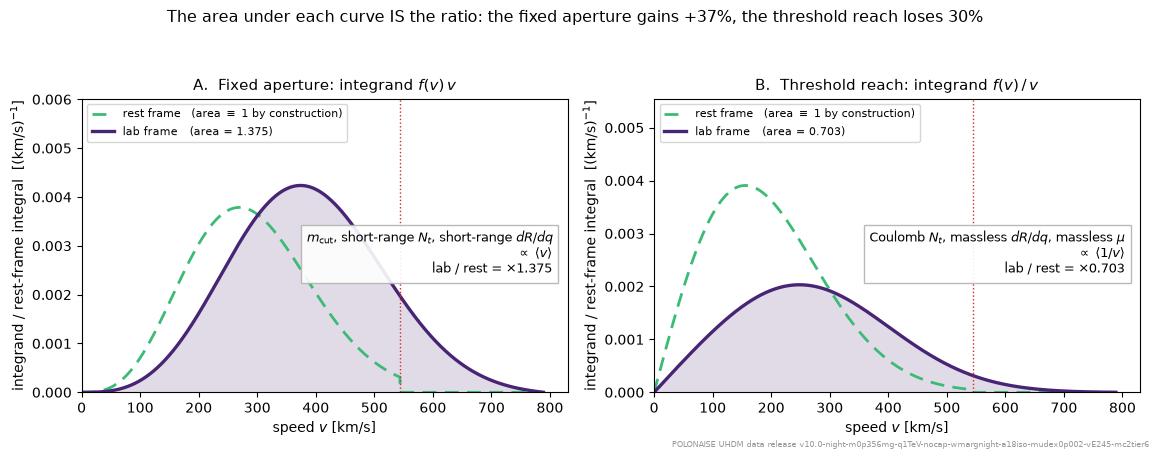

In [6]:
# The two integrands, each divided by its own REST-frame integral. That choice
# is the whole point of the figure: the area under a curve is then literally the
# lab/rest ratio for that observable, 1.000 by construction for the dashed
# curves. Normalising each curve to unit area instead -- the reflex -- would
# hide exactly the quantity being compared.
I_FLUX = float(np.trapezoid(F_REST * V, V))      # = <v>   (rest frame)
I_THR = float(np.trapezoid(F_REST / V, V))       # = <1/v> (rest frame)
# decimated for drawing; the two integrals above are the fine-grid ones
W_FLUX_R, W_FLUX_L = FD_REST * VD, FD_LAB * VD
W_THR_R, W_THR_L = FD_REST / VD, FD_LAB / VD

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.6, 4.5), sharex=True)
for ax, wr, wl, scale, title, sub, ratio in (
        (axA, W_FLUX_R, W_FLUX_L, I_FLUX,
         r"A.  Fixed aperture: integrand $f(v)\,v$",
         r"$m_{\rm cut}$, short-range $N_t$, short-range $dR/dq$"
         "\n" r"$\propto\ \langle v\rangle$", R_VMEAN),
        (axB, W_THR_R, W_THR_L, I_THR,
         r"B.  Threshold reach: integrand $f(v)\,/\,v$",
         r"Coulomb $N_t$, massless $dR/dq$, massless $\mu$"
         "\n" r"$\propto\ \langle 1/v\rangle$", R_INV)):
    # divide by KMS to turn a per-(natural speed) density into per-(km/s), so
    # the area read off the km/s axis really is the dimensionless ratio
    yr, yl = wr / scale / KMS, wl / scale / KMS
    vplot = VD * KMS
    ax.fill_between(vplot, 0, yl, color=C_LAB, alpha=0.16, lw=0)
    ax.plot(vplot, yr, color=C_REST, lw=2.0, ls=(0, (5, 3)),
            label="rest frame   (area $\\equiv$ 1 by construction)")
    ax.plot(vplot, yl, color=C_LAB, lw=2.4,
            label=f"lab frame   (area = {ratio:.3f})")
    ax.axvline(VESC_KMS, color=C_EDGE, lw=1.0, ls=":")
    ax.set_xlim(0, 830)
    ax.set_ylim(0, None)
    ax.set_xlabel(r"speed $v$ [km/s]")
    ax.set_ylabel("integrand / rest-frame integral  [(km/s)$^{-1}$]")
    ax.set_title(title, fontsize=11)
    ax.text(0.97, 0.55, sub + "\n" + rf"lab / rest = $\times${ratio:.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(fc="white", ec="0.7", alpha=0.9))
    ax.set_ylim(0, max(yr.max(), yl.max()) * 1.42)
    ax.legend(fontsize=8, loc="upper left")
    # the areas, verified rather than asserted by eye
    assert abs(np.trapezoid(yr, vplot) - 1.0) < 1e-4
    assert abs(np.trapezoid(yl, vplot) - ratio) < 1e-4

fig.suptitle("The area under each curve IS the ratio: the fixed aperture gains "
             f"{R_VMEAN - 1:+.0%}, the threshold reach loses {1 - R_INV:.0%}",
             fontsize=11.5)
fig.tight_layout(rect=(0, 0, 1, 0.93))
save_figure(fig, "06_moment_weightings")
plt.show()

In [7]:
# ---- consequence 1: the flux cut m_cut ---------------------------------------
# recomputed from first principles and cross-checked against the released
# attribute, IN WHICHEVER FRAME THAT CUBE WAS BUILT: m_cut scales with <v>, so
# a lab-frame cube's attribute is 1.375x the rest-frame one and comparing it to
# the rest-frame recompute would fail by construction.
key = next(k for k in rel.attrs if k.startswith("m_cut_") and k.endswith("_gev"))
M_CUT_ATTR = float(rel.attrs[key])
N_REQ = float(rel.attrs["m_cut_n_transits_required"])
B_CAP = float(rel.attrs["m_cut_b_cap_m"])
RHO_0 = 3.0e5                                   # GeV/m^3 = 0.3 GeV/cm^3
F_DM_ATTR = float(rel.f_dm_values[0])


def m_cut(v_mean_nu, f_dm):
    return (f_dm * RHO_0 * (v_mean_nu * units.C_M_S) * T_TOTAL
            * np.pi * B_CAP ** 2 / N_REQ)


CUBE_V_E_KMS = float(rel.attrs.get("v_earth_km_s", 0.0))
V_MEAN_CUBE = V_MEAN_LAB if CUBE_V_E_KMS else V_MEAN_REST
assert abs(CUBE_V_E_KMS - (V_E_KMS if CUBE_V_E_KMS else 0.0)) < 1e-9, \
    "the cube's frame is neither the rest frame nor this notebook's lab frame"
assert abs(m_cut(V_MEAN_CUBE, F_DM_ATTR) / M_CUT_ATTR - 1) < 2e-4, \
    "the m_cut recompute disagrees with the released attribute in its own frame"
print(f"released {key} = {M_CUT_ATTR:.4e} GeV   "
      f"(recomputed {m_cut(V_MEAN_CUBE, F_DM_ATTR):.4e}, "
      f"cube frame v_E = {CUBE_V_E_KMS:g} km/s)")

print(f"\n{'f_DM':>6}{'m_cut rest [GeV]':>20}{'m_cut lab [GeV]':>18}{'ratio':>9}")
for f_dm in (0.1, 1.0):
    a, b = m_cut(V_MEAN_REST, f_dm), m_cut(V_MEAN_LAB, f_dm)
    print(f"{f_dm:>6g}{a:>20.4e}{b:>18.4e}{b / a:>9.4f}")

M_CUT_REST_F1 = m_cut(V_MEAN_REST, 1.0)
M_CUT_LAB_F1 = m_cut(V_MEAN_LAB, 1.0)
assert abs(M_CUT_REST_F1 / 6.11e14 - 1) < 5e-3, "m_cut(f_DM=1) rest moved"
assert abs(M_CUT_LAB_F1 / 8.40e14 - 1) < 5e-3, "m_cut(f_DM=1) lab moved"
assert abs(M_CUT_LAB_F1 / M_CUT_REST_F1 - R_VMEAN) < 1e-9, \
    "m_cut must scale exactly as <v>"
print(f"\nm_cut is exactly proportional to <v>: the right-hand edge of every "
      f"excluded region\nmoves out by x{R_VMEAN:.3f}, "
      f"{M_CUT_REST_F1:.3g} -> {M_CUT_LAB_F1:.3g} GeV at f_DM = 1 "
      f"(N_req = {N_REQ:g}).")

released m_cut_10cm_f0.1_gev = 8.4012e+13 GeV   (recomputed 8.4012e+13, cube frame v_E = 245 km/s)

  f_DM    m_cut rest [GeV]   m_cut lab [GeV]    ratio
   0.1          6.1107e+13        8.4012e+13   1.3748
     1          6.1107e+14        8.4012e+14   1.3748

m_cut is exactly proportional to <v>: the right-hand edge of every excluded region
moves out by x1.375, 6.11e+14 -> 8.4e+14 GeV at f_DM = 1 (N_req = 3).


<a id="4"></a>
## 4. Verification against the shipped halo shards

The moments above are computed here from scratch. The transit-count claim can be
checked against something built independently: the `halo` pass of the two release
builds, which computes $N_t$ and the flux-averaged reach on a 64 × 64
(mass, coupling) grid per mediator range. The two builds share seed, exposure,
grids and projection kernel and differ **only** in `--v-earth`, which each shard
records in a `v_earth_km_s` key. So a shard-to-shard ratio isolates the frame
change and nothing else.

The prediction, per mediator range:

| reach | scaling of $N_t$ | predicted lab/rest |
|---|---|---|
| massless (Coulomb), $b_\text{max}\propto 1/v$ | $\langle 1/v\rangle$ | 0.703 |
| short range, $b_\text{max}\approx\lambda$ fixed | $\langle v\rangle$ | 1.375 |

Everything in between should land between them. Note the shards are *inputs to*
this check, not the source of the numbers: the two bracketing values come from
§3.

In [8]:
# Both shard dirs are local BUILD artefacts, not shipped with the release:
# the rest-frame set is what a v_E = 0 campaign wrote. Override via env,
# and skip cleanly if they are not present rather than fail on a path.
SHARD_REST = Path(os.environ.get("LUHDM_SHARDS_REST",
                  Path.home() / "code/uhdm/release_shards_v9p1/halo"))
SHARD_LAB = Path(os.environ.get("LUHDM_SHARDS_LAB",
                 Path.home() / "code/uhdm/release_shards_v10/halo"))
HAVE_SHARDS = SHARD_REST.is_dir() and SHARD_LAB.is_dir()
if not HAVE_SHARDS:
    print(f"halo shard dirs not found ({SHARD_REST}, {SHARD_LAB}); "
          "skipping the shard cross-check. Set LUHDM_SHARDS_REST / "
          "LUHDM_SHARDS_LAB to run it.")

SHARDS = [("massless", "massless", r"massless", None),
          ("il03", "lambda = 200 m", r"$\lambda$ = 200 m", 200.0),
          ("il02", "lambda = 2 mm", r"$\lambda$ = 2 mm", 2e-3),
          ("il01", "lambda = 200 um", r"$\lambda$ = 200 $\mu$m", 2e-4),
          ("il00", "lambda = 20 um", r"$\lambda$ = 20 $\mu$m", 2e-5)]

rows = []
for tag, plain, label, lam in (SHARDS if HAVE_SHARDS else []):
    a = np.load(SHARD_REST / f"shard_halo_{tag}.npz", allow_pickle=True)
    b = np.load(SHARD_LAB / f"shard_halo_{tag}.npz", allow_pickle=True)
    # the two builds must differ in the frame and in nothing else
    assert float(a.get("v_earth_km_s", 0.0)) == 0.0
    assert float(b["v_earth_km_s"]) == V_E_KMS
    assert np.array_equal(a["ms"], b["ms"]) and np.array_equal(
        a["alphas_n"], b["alphas_n"])
    assert str(a["projection_kernel"]) == str(b["projection_kernel"])
    assert int(a["seed"]) == int(b["seed"]) and float(a["t_total"]) == float(
        b["t_total"])
    live = (a["nt"] > 0) & (b["nt"] > 0)
    r = b["nt"][live] / a["nt"][live]
    rows.append((plain, label, lam, int(live.sum()), float(np.median(r)),
                 float(np.percentile(r, 25)), float(np.percentile(r, 75))))

print(f"halo shards: {SHARD_REST.parent.name} (v_E = 0) vs "
      f"{SHARD_LAB.parent.name} (v_E = {V_E_KMS:.0f} km/s)\n")
print(f"{'range':>16}{'cells':>8}{'median N_t ratio':>19}{'IQR over the grid':>24}")
for plain, label, lam, n, med, q1, q3 in rows:
    print(f"{plain:>16}{n:>8d}{med:>19.4f}{f'[{q1:.3f}, {q3:.3f}]':>24}")
print(f"\npredicted bracket from section 3:  <1/v> ratio {R_INV:.4f}  ..  "
      f"<v> ratio {R_VMEAN:.4f}")
print("(the wide IQRs are the cells where the reach is comparable to R_eff or "
      "to lambda,\n where b_max(v) is neither pure 1/v nor constant; the "
      "medians are the clean regimes.)")

MED = ({label: med for plain, label, lam, n, med, q1, q3 in rows} if rows
       else {label: float("nan") for tag, plain, label, lam in SHARDS})
# these check the shard table, so they only apply when the shards were read
if HAVE_SHARDS:
    assert abs(MED["massless"] - R_INV) < 0.005, \
        "the massless shard N_t ratio does not reproduce the <1/v> ratio"
    assert R_INV - 0.01 < MED[r"$\lambda$ = 200 m"] < R_INV + 0.02, \
        "the 200 m shard should sit essentially on the Coulomb limit"
    assert MED[r"$\lambda$ = 20 $\mu$m"] < R_VMEAN, \
        "no shard may exceed the fixed-aperture limit"
    assert all(R_INV - 0.01 < med < R_VMEAN + 0.01 for med in MED.values()), \
        "a shard N_t ratio fell outside the two-moment bracket"

halo shards: release_shards_v9p1 (v_E = 0) vs release_shards_v10 (v_E = 245 km/s)

           range   cells   median N_t ratio       IQR over the grid
        massless    3737             0.7041          [0.704, 0.704]
  lambda = 200 m    3737             0.7043          [0.704, 0.896]
   lambda = 2 mm    3736             1.2268          [0.800, 1.306]
 lambda = 200 um    3719             1.2714          [0.833, 1.319]
  lambda = 20 um    3606             1.3335          [0.320, 1.345]

predicted bracket from section 3:  <1/v> ratio 0.7034  ..  <v> ratio 1.3748
(the wide IQRs are the cells where the reach is comparable to R_eff or to lambda,
 where b_max(v) is neither pure 1/v nor constant; the medians are the clean regimes.)


In [9]:
# the deep-Coulomb subset: cells whose reach is far above the sensor radius, so
# the b > R_eff inner cutoff is not shaping the answer. There the massless shard
# ratio should be the <1/v> ratio to a fraction of a percent, the residual being
# the 200-point geomspace quadrature the build uses versus the fine linear grid
# of section 3.
# same guard as the cell above: the rest-frame shard build is a local artefact,
# not part of any release, so skip rather than fail on a checkout without it.
if HAVE_SHARDS:
    a = np.load(SHARD_REST / "shard_halo_massless.npz", allow_pickle=True)
    b = np.load(SHARD_LAB / "shard_halo_massless.npz", allow_pickle=True)
    deep = (a["bmax_m"] > 50 * R_eff) & (b["bmax_m"] > 50 * R_eff) & (a["nt"] > 0)
    r_nt = np.median(b["nt"][deep] / a["nt"][deep])
    r_b = np.median(b["bmax_m"][deep] / a["bmax_m"][deep])
else:
    r_nt = r_b = float("nan")
    print("halo shard dirs absent; skipping the deep-Coulomb shard cross-check.")

# the same quadrature, reproduced here: rate.transit_count_halo integrates on a
# 200-point geomspace from q_th/m to V_MAX, which is a coarser rule than the
# 2e6-point linear grid above -- so the small residual is quadrature, not physics
def nt_weight_ratio(m_gev, n=200):
    out = []
    for v_e in (0.0, V_E_KMS):
        with halo_frame(v_e) as f_v:
            vs = np.geomspace(max(Q_THRESH / m_gev, 1e-8), config.V_MAX, n)
            out.append(float(np.trapezoid(f_v(vs) / vs, vs)))
    return out[1] / out[0]


R_NT_QUAD = nt_weight_ratio(1e12)

if HAVE_SHARDS:
    print(f"deep-Coulomb cells (b_max > 50 R_eff): {int(deep.sum())}")
    print(f"  N_t   ratio from the shards          {r_nt:.5f}")
    print(f"  same quadrature, recomputed here     {R_NT_QUAD:.5f}")
    print(f"  exact <1/v> ratio (fine grid)        {R_INV:.5f}")
    print(f"  -> shards vs exact: {abs(r_nt / R_INV - 1):.2%}, "
          f"shards vs same-quadrature: {abs(r_nt / R_NT_QUAD - 1):.2e}")
    assert abs(r_nt / R_NT_QUAD - 1) < 2e-3, \
        "the shards do not reproduce their own quadrature's <1/v> ratio"
else:
    print(f"  same quadrature, recomputed here     {R_NT_QUAD:.5f}")
    print(f"  exact <1/v> ratio (fine grid)        {R_INV:.5f}")

# the flux-averaged reach sqrt(<b^2>) carries <1/v>/<v> under the Coulomb b(v)
R_B_PRED = np.sqrt(R_INV / R_VMEAN)
if HAVE_SHARDS:
    print(f"\nflux-averaged reach sqrt(<pi b^2>/pi):  shards {r_b:.5f}, "
          f"predicted sqrt(<1/v>/<v>) = {R_B_PRED:.5f}  "
          f"({abs(r_b / R_B_PRED - 1):.2%})")
    assert abs(r_b / R_B_PRED - 1) < 5e-3, \
        "the flux-averaged reach does not scale as sqrt(<1/v>/<v>)"
else:
    print(f"\npredicted sqrt(<1/v>/<v>) = {R_B_PRED:.5f} (no shards to compare)")

deep-Coulomb cells (b_max > 50 R_eff): 2338
  N_t   ratio from the shards          0.70405
  same quadrature, recomputed here     0.70405
  exact <1/v> ratio (fine grid)        0.70340
  -> shards vs exact: 0.09%, shards vs same-quadrature: 0.00e+00

flux-averaged reach sqrt(<pi b^2>/pi):  shards 0.71368, predicted sqrt(<1/v>/<v>) = 0.71528  (0.22%)


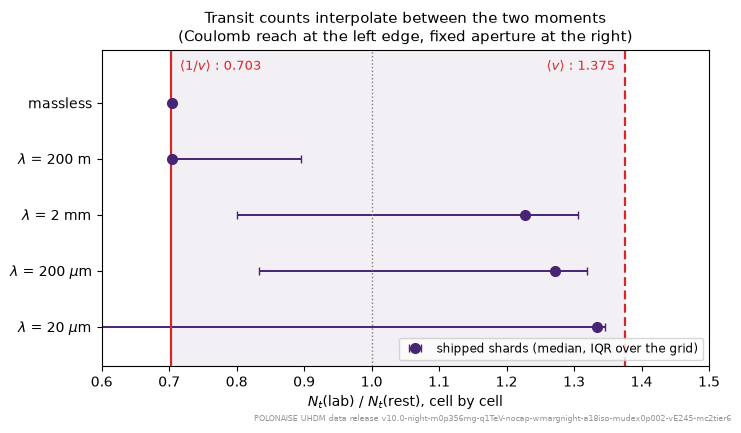

In [10]:
fig, ax = plt.subplots(figsize=(7.4, 4.3))
labels = [r[1] for r in rows]
meds = [r[4] for r in rows]
lo = [r[4] - r[5] for r in rows]
hi = [r[6] - r[4] for r in rows]
ypos = np.arange(len(rows))[::-1]
ax.errorbar(meds, ypos, xerr=[lo, hi], fmt="o", ms=7, color=C_LAB, lw=1.4,
            capsize=3, label="shipped shards (median, IQR over the grid)")
ax.axvline(R_INV, color=C_EDGE, lw=1.6)
ax.text(R_INV, len(rows) - 0.35, rf"  $\langle 1/v\rangle$ : {R_INV:.3f}",
        color=C_EDGE, fontsize=9.5, va="center")
ax.axvline(R_VMEAN, color=C_EDGE, lw=1.6, ls=(0, (4, 2)))
ax.text(R_VMEAN, len(rows) - 0.35, rf"$\langle v\rangle$ : {R_VMEAN:.3f}  ",
        color=C_EDGE, fontsize=9.5, va="center", ha="right")
ax.axvline(1.0, color="#7f7f7f", lw=1.0, ls=":")
ax.axvspan(R_INV, R_VMEAN, color=C_LAB, alpha=0.07, lw=0)
ax.set_yticks(ypos)
ax.set_yticklabels(labels)
ax.set_ylim(-0.7, len(rows) - 0.05)
ax.set_xlim(0.6, 1.5)
ax.set_xlabel(r"$N_t$(lab) / $N_t$(rest), cell by cell")
ax.set_title("Transit counts interpolate between the two moments\n"
             "(Coulomb reach at the left edge, fixed aperture at the right)",
             fontsize=11)
ax.legend(fontsize=8.5, loc="lower right")
fig.tight_layout()
save_figure(fig, "06_shard_transit_ratios")
plt.show()

<a id="5"></a>
## 5. $dR/dq$: the shape change, not just the normalisation

The differential rate is

$$\frac{dR}{dq} \;=\; n_\text{DM}\int_{q/m_\text{DM}}^{v_\text{max}}
f(v)\,v\,\frac{d\sigma}{dq}(q, v)\,dv ,$$

and the frame enters through **three** places at once, which is why the curves do
not simply slide:

1. **$f(v)$ itself** — the shape from §2.
2. **The lower limit $q/m_\text{DM}$** — no particle can deliver more than
   $q = m_\text{DM} v$, so the spectrum ends at
   $q_\text{kin} = m_\text{DM}\,v_\text{max}$, which moves out by
   $(v_\text{esc}+v_E)/v_\text{esc}$ = 1.45. *This is the mechanism behind the
   mass-window shift*: a lighter particle can now reach the analysis window.
3. **The cross section's own speed dependence.** For a massless mediator
   $d\sigma/dq \propto \alpha^2/(v^2 q^3)$ times the shell factor
   $1 - (q/q_\text{max})^3$, with $q_\text{max} = 2\alpha/(v R_\text{eff})$ —
   which *falls* with $v$. So the endpoint imposed by the sensor radius moves the
   *other* way: fast particles are cut off sooner.

Point 3 is what decides the **sign**, and it is the same bracket as §4. In the
bulk of the spectrum the two mediator limits behave completely differently:

* **Massless (Coulomb):** $d\sigma/dq \propto 1/v^2$, so
  $f(v)\,v\,d\sigma/dq \propto f(v)/v$ and
  $dR/dq \propto \langle 1/v\rangle$ — **down** by 0.703.
* **Short range (Yukawa):** for $b \gg \lambda$ the impulse falls exponentially,
  $|\partial q/\partial b| \simeq q/\lambda$, so
  $d\sigma/dq \simeq 2\pi\lambda\,b(q)/q$ with $b(q) \simeq \lambda\ln(\cdot)$ —
  **essentially independent of $v$**, up to a logarithm. Then
  $dR/dq \propto \langle v\rangle$ — **up** by ~1.375.

So the same two moments that bracketed the transit counts in §4 bracket the
*rates*, for the same reason: the speed dependence of the reach. A finite-range
search is **helped** by the lab frame; a massless one is **hurt**. The 200 µm
panel below lands at 1.33, just inside the $\langle v\rangle$ limit, and the
massless panel at 0.704, exactly on the $\langle 1/v\rangle$ one.

Point 3 has a second face, and it is worth pausing on. Requiring the reach to clear the sensor,
$b_\text{max} = 2\alpha/(q v) > R_\text{eff}$, is the statement
$v < v_* = 2\alpha/(q R_\text{eff})$: **only particles slower than $v_*$ can
deliver a kick of size $q$ at all.** At bulk couplings $v_*$ is far above the
halo and this does nothing; near the coupling floor $v_*$ sits inside the halo,
the window is fed by the slow tail alone, and the boost — which drains exactly
that tail — bites hard. Both regimes are drawn below.

Every cross-section handle here comes from `rel.make_xsec(...)`, which threads the
released file's `projection_kernel` (`isotropic-folded`) and its impact-parameter
cap. `luhdm.rate.make_xsec` would silently take the module default
(`planar-signed`) and is a 13–33% error; notebook 02 demonstrates this on a
stored cell.

In [11]:
XS_MASSLESS = rel.make_xsec(None)          # released kernel + cap, massless
XS_200UM = rel.make_xsec(2e-4)             # released kernel + cap, 200 um


def drdq(qs, m_gev, alpha_n, xs, v_e_km_s, f_dm=1.0, mode=None):
    """Raw dR/dq [s^-1 GeV^-1] in one halo frame, bare halo (no atmosphere).

    The with-block supplies BOTH the f(v) and the config.V_MAX that
    rate.differential_rate_trapz integrates up to, so the two cannot disagree.
    """
    eff = None if mode is None else efficiency.make_efficiency(mode, df=3)
    with halo_frame(v_e_km_s) as f_v:
        r = rate.differential_rate_trapz(qs, alpha_n, m_gev, f_v, xs, eff=eff)
    return r * (float(f_dm) / config.F_X)


M_SHOW = 1e8            # showcase DM mass [GeV]
A_BULK = 1e-3           # bulk coupling: q_max far above the window
A_FLOOR = 2.5e-9        # near the massless coupling floor (notebook 02: 2.55e-9)

ALPHA_BULK = A_BULK * config.N_NEUTRONS
ALPHA_FLOOR = A_FLOOR * config.N_NEUTRONS
print(f"showcase: m_DM = {M_SHOW:.0e} GeV, massless mediator")
print(f"  kinematic endpoint q_kin = m v_max : "
      f"{M_SHOW * V_MAX_REST:.3e} -> {M_SHOW * V_MAX_LAB:.3e} GeV "
      f"(x{V_MAX_LAB / V_MAX_REST:.3f})")
for tag, alpha in (("bulk  alpha_n = 1e-3 ", ALPHA_BULK),
                   ("floor alpha_n = 2.5e-9", ALPHA_FLOOR)):
    v_star = 2 * alpha / (Q_THRESH * units.conv_m2pGeV(R_eff))
    print(f"  {tag}: v* = 2 alpha/(q_th R_eff) = {v_star * KMS:.3e} km/s "
          f"-> only v < v* reaches the window "
          f"({'the whole halo' if v_star > V_MAX_LAB else 'a slow slice of it'})")

showcase: m_DM = 1e+08 GeV, massless mediator
  kinematic endpoint q_kin = m v_max : 1.815e+05 -> 2.632e+05 GeV (x1.450)
  bulk  alpha_n = 1e-3 : v* = 2 alpha/(q_th R_eff) = 4.850e+07 km/s -> only v < v* reaches the window (the whole halo)
  floor alpha_n = 2.5e-9: v* = 2 alpha/(q_th R_eff) = 1.213e+02 km/s -> only v < v* reaches the window (a slow slice of it)


In [12]:
Q_A = np.geomspace(Q_THRESH, 6e5, 220)     # spans both kinematic endpoints
Q_C = np.geomspace(Q_THRESH, 2e4, 220)     # the floor case dies far sooner

CURVES = {}
CURVES["bulk_rest"] = drdq(Q_A, M_SHOW, A_BULK, XS_MASSLESS, 0.0)
CURVES["bulk_lab"] = drdq(Q_A, M_SHOW, A_BULK, XS_MASSLESS, V_E_KMS)
CURVES["floor_rest"] = drdq(Q_C, M_SHOW, A_FLOOR, XS_MASSLESS, 0.0)
CURVES["floor_lab"] = drdq(Q_C, M_SHOW, A_FLOOR, XS_MASSLESS, V_E_KMS)
CURVES["l200_rest"] = drdq(Q_A, M_SHOW, A_BULK, XS_200UM, 0.0)
CURVES["l200_lab"] = drdq(Q_A, M_SHOW, A_BULK, XS_200UM, V_E_KMS)

# the bulk plateau: far below any endpoint the massless rate is alpha^2/q^3
# times <1/v>, so the ratio must BE the <1/v> ratio
i_bulk = int(np.argmin(np.abs(Q_A - 3e3)))
RATIO_BULK = CURVES["bulk_lab"][i_bulk] / CURVES["bulk_rest"][i_bulk]
print(f"massless, bulk coupling, q = {Q_A[i_bulk]:.3g} GeV: "
      f"dR/dq ratio = {RATIO_BULK:.4f}   (<1/v> ratio {R_INV:.4f})")
assert abs(RATIO_BULK - R_INV) < 0.01, \
    "the bulk massless dR/dq ratio is not the <1/v> ratio"

# the endpoints, read off where each curve dies
def endpoint(qs, r):
    nz = np.flatnonzero(r > 0)
    return float(qs[nz[-1]]) if nz.size else float("nan")


E_REST, E_LAB = endpoint(Q_A, CURVES["bulk_rest"]), endpoint(Q_A, CURVES["bulk_lab"])
print(f"measured spectrum endpoint: {E_REST:.3e} -> {E_LAB:.3e} GeV "
      f"(x{E_LAB / E_REST:.3f}); predicted m v_max ratio "
      f"{V_MAX_LAB / V_MAX_REST:.3f}")
assert abs(E_LAB / E_REST / (V_MAX_LAB / V_MAX_REST) - 1) < 0.05, \
    "the spectrum endpoint does not move with v_max"

i_fl = int(np.argmin(np.abs(Q_C - 1.2e3)))
RATIO_FLOOR = CURVES["floor_lab"][i_fl] / CURVES["floor_rest"][i_fl]
print(f"massless, floor coupling, q = {Q_C[i_fl]:.3g} GeV: "
      f"dR/dq ratio = {RATIO_FLOOR:.4f}   -- far below the bulk value, because "
      f"only\n  the slow tail (v < v*) contributes at all and the boost drains it")
assert RATIO_FLOOR < 0.5 * R_INV, \
    "the near-floor suppression should be much stronger than the bulk one"

i200 = int(np.argmin(np.abs(Q_A - 3e3)))
RATIO_200 = CURVES["l200_lab"][i200] / CURVES["l200_rest"][i200]
print(f"200 um, bulk coupling, q = {Q_A[i200]:.3g} GeV: "
      f"dR/dq ratio = {RATIO_200:.4f}   -- ABOVE one: a finite-range reach is a\n"
      f"  near-fixed aperture, so its rate follows <v> ({R_VMEAN:.4f}), not "
      f"<1/v>")
assert 1.0 < RATIO_200 < R_VMEAN, \
    "the finite-range dR/dq ratio must sit between 1 and the <v> ratio"

massless, bulk coupling, q = 3.03e+03 GeV: dR/dq ratio = 0.7042   (<1/v> ratio 0.7034)
measured spectrum endpoint: 1.759e+05 -> 2.572e+05 GeV (x1.462); predicted m v_max ratio 1.450
massless, floor coupling, q = 1.19e+03 GeV: dR/dq ratio = 0.3075   -- far below the bulk value, because only
  the slow tail (v < v*) contributes at all and the boost drains it
200 um, bulk coupling, q = 3.03e+03 GeV: dR/dq ratio = 1.3320   -- ABOVE one: a finite-range reach is a
  near-fixed aperture, so its rate follows <v> (1.3748), not <1/v>


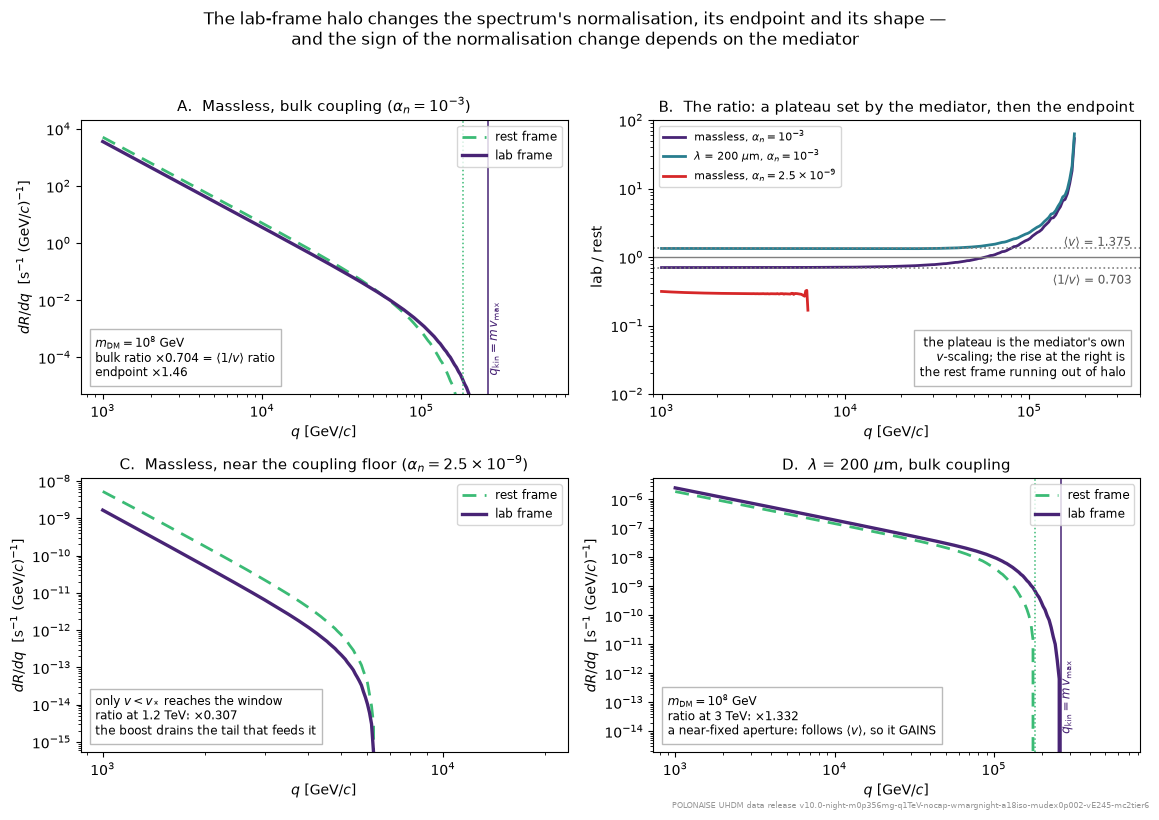

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.2))
(axA, axB), (axC, axD) = axes


def frame_pair(ax, qs, key, title, note, qkin=True):
    ax.loglog(qs, CURVES[key + "_rest"], color=C_REST, lw=2.0, ls=(0, (5, 3)),
              label="rest frame")
    ax.loglog(qs, CURVES[key + "_lab"], color=C_LAB, lw=2.4, label="lab frame")
    if qkin:
        for v_max, c, ls in ((V_MAX_REST, C_REST, ":"), (V_MAX_LAB, C_LAB, "-")):
            ax.axvline(M_SHOW * v_max, color=c, lw=1.1, ls=ls)
        ax.text(M_SHOW * V_MAX_LAB, 0.04,
                r"  $q_{\rm kin} = m\,v_{\rm max}$", color=C_LAB, fontsize=8.5,
                rotation=90, ha="left", va="bottom",
                transform=ax.get_xaxis_transform())
    ax.set_xlabel(r"$q$ [GeV/$c$]")
    ax.set_ylabel(r"$dR/dq$  [s$^{-1}$ (GeV/$c$)$^{-1}$]")
    ax.set_title(title, fontsize=11)
    ax.text(0.03, 0.05, note, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=8.5, bbox=dict(fc="white", ec="0.7", alpha=0.9))
    ax.legend(fontsize=8.5, loc="upper right")


frame_pair(axA, Q_A, "bulk",
           r"A.  Massless, bulk coupling ($\alpha_n = 10^{-3}$)",
           rf"$m_{{\rm DM}} = 10^{{8}}$ GeV" "\n"
           rf"bulk ratio $\times${RATIO_BULK:.3f} = $\langle 1/v\rangle$ ratio"
           "\n" rf"endpoint $\times${E_LAB / E_REST:.2f}")
axA.set_ylim(bottom=max(CURVES["bulk_rest"].max() * 1e-9, 1e-40))

# B: the ratio, which is where the shape change actually reads
for key, qs, c, lab in (("bulk", Q_A, C_LAB, r"massless, $\alpha_n = 10^{-3}$"),
                        ("l200", Q_A, plt.cm.viridis(0.42),
                         r"$\lambda$ = 200 $\mu$m, $\alpha_n = 10^{-3}$"),
                        ("floor", Q_C, C_EDGE, r"massless, $\alpha_n = 2.5\times10^{-9}$")):
    r_rest, r_lab = CURVES[key + "_rest"], CURVES[key + "_lab"]
    ok = r_rest > 0
    axB.loglog(qs[ok], r_lab[ok] / r_rest[ok], color=c, lw=2.0, label=lab)
for lvl, txt, dy in ((R_INV, rf"$\langle 1/v\rangle$ = {R_INV:.3f}", 0.58),
                     (R_VMEAN, rf"$\langle v\rangle$ = {R_VMEAN:.3f}", 1.06)):
    axB.axhline(lvl, color="#7f7f7f", lw=1.2, ls=":")
    axB.text(3.6e5, lvl * dy, txt, fontsize=8.5, color="#555555", ha="right")
axB.axhline(1.0, color="#7f7f7f", lw=1.0)
axB.set_xlabel(r"$q$ [GeV/$c$]")
axB.set_ylabel("lab / rest")
axB.set_ylim(1e-2, 1e2)
axB.set_xlim(9e2, 4e5)
axB.set_title("B.  The ratio: a plateau set by the mediator, then the endpoint",
              fontsize=11)
axB.legend(fontsize=8, loc="upper left")
axB.text(0.97, 0.05,
         "the plateau is the mediator's own\n"
         r"$v$-scaling; the rise at the right is"
         "\nthe rest frame running out of halo",
         transform=axB.transAxes, ha="right", va="bottom", fontsize=8.5,
         bbox=dict(fc="white", ec="0.7", alpha=0.9))

frame_pair(axC, Q_C, "floor",
           r"C.  Massless, near the coupling floor ($\alpha_n = 2.5\times10^{-9}$)",
           rf"only $v < v_*$ reaches the window" "\n"
           rf"ratio at 1.2 TeV: $\times${RATIO_FLOOR:.3f}" "\n"
           "the boost drains the tail that feeds it", qkin=False)
axC.set_ylim(bottom=max(CURVES["floor_rest"].max() * 1e-7, 1e-40))

frame_pair(axD, Q_A, "l200",
           r"D.  $\lambda$ = 200 $\mu$m, bulk coupling",
           rf"$m_{{\rm DM}} = 10^{{8}}$ GeV" "\n"
           rf"ratio at 3 TeV: $\times${RATIO_200:.3f}" "\n"
           r"a near-fixed aperture: follows $\langle v\rangle$, so it GAINS")
axD.set_ylim(bottom=max(CURVES["l200_rest"].max() * 1e-9, 1e-40))

fig.suptitle("The lab-frame halo changes the spectrum's normalisation, its "
             "endpoint and its shape —\nand the sign of the normalisation "
             "change depends on the mediator", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96))
save_figure(fig, "06_spectra_two_frames")
plt.show()

<a id="6"></a>
## 6. The expected count $\mu$ in the analysis window

$\mu$ is the integral of the *detected* rate over the analysis window,
$\mu = T\int_{q_\text{th}}^{\infty}\varepsilon(q)\,\frac{dR}{dq}\,dq$ — the one
number the optimum interval turns into an exclusion. This is the frame effect
that actually reaches the limits, and **it is not a single factor.** It depends
on the mediator range, on the mass, and on where in the coupling plane you stand.

Read the ratio panel below from the right:

* **Heavy masses, bulk coupling, massless mediator.** $q_\text{th}/m_\text{DM}$
  is far below any halo speed and $q_\text{max}$ far above the window, so the
  rate is $\alpha^2/q^3$ times $\langle 1/v\rangle$ and the ratio is *exactly*
  the $\langle 1/v\rangle$ ratio, 0.703, independent of mass and coupling. The
  lab frame **loses about 30% of the expected count**.
* **Heavy masses, bulk coupling, finite range.** The same limit with the other
  moment: the ratio plateaus a little below $\langle v\rangle$ = 1.375, and the
  lab frame **gains**. Massless and finite-range slices of the same cube move in
  *opposite directions*.
* **Light masses, approaching the wall.** The rest frame is running out of halo:
  the window needs $v \ge q_\text{th}/m_\text{DM}$, and the rest frame has less
  and less of it. Both mediators' ratios rise through 1 and diverge.
* **Near the coupling floor, at any mass.** The window is fed only by
  $v < v_* = 2\alpha/(q R_\text{eff})$ — the slow tail — and the boost drains it.
  The ratio drops to about 0.30, well below $\langle 1/v\rangle$.

So a single "$\mu$ ratio" is not a meaningful quantity: it is a function of
$(m_\text{DM}, \alpha_n, \lambda)$, and the regimes drawn below span a factor
of four.

*A note on two numbers in circulation.* The project notes quote $\mu$ ratios of
~0.32 at $m_\text{DM} = 7.1\times10^6$ GeV and ~0.70 at $1.5\times10^8$ GeV "at
fixed $\alpha$". The cell below reproduces both values, but they are **not at
the same coupling**: 0.32 is the *coupling-floor* value (it is ~0.30 at
$1.5\times10^8$ GeV too) and 0.70 is the *bulk* value (it is ~0.77 at
$7.1\times10^6$ GeV). The contrast between them is a coupling effect, not a mass
effect — the mass dependence is the much milder 0.77 → 0.70 walk onto the
asymptote.

In [14]:
QS_BUILD = np.geomspace(Q_THRESH, 3e4 * 8.4e3, 240)   # the release build's grid
MODE = 1
EPS = efficiency.make_efficiency(MODE, df=3)


def mu_window(m_gev, alpha_n, xs, v_e_km_s, f_dm=1.0):
    """Expected DETECTED counts in the analysis window, one frame, bare halo."""
    with halo_frame(v_e_km_s) as f_v:
        dr = rate.differential_rate_trapz(QS_BUILD, alpha_n, m_gev, f_v, xs,
                                          eff=None) * EPS(QS_BUILD)
        spec = limits.spectrum_from_rate(QS_BUILD, dr, T_TOTAL)
    return 0.0 if spec is None else (f_dm / config.F_X) * spec[0]


MS = np.geomspace(3.2e5, 1e13, 70)
CASES = [("massless, $\\alpha_n = 10^{-3}$ (bulk)", XS_MASSLESS, A_BULK, C_LAB),
         ("$\\lambda$ = 200 $\\mu$m, $\\alpha_n = 10^{-3}$", XS_200UM, A_BULK,
          plt.cm.viridis(0.42)),
         ("massless, $\\alpha_n = 2.5\\times10^{-9}$ (floor)", XS_MASSLESS,
          A_FLOOR, C_EDGE)]

MU = {}
for label, xs, a_n, _c in CASES:
    MU[label] = (np.array([mu_window(m, a_n, xs, 0.0) for m in MS]),
                 np.array([mu_window(m, a_n, xs, V_E_KMS) for m in MS]))
print("mu computed on %d masses x %d cases x 2 frames" % (MS.size, len(CASES)))

mu computed on 70 masses x 3 cases x 2 frames


In [15]:
# the two masses quoted in the project notes, spelled out at both couplings
print(f"{'m_DM [GeV]':>12}{'alpha_n':>12}{'mu rest':>13}{'mu lab':>13}"
      f"{'lab/rest':>10}")
QUOTED = {}
for m_q in (7.1e6, 1.5e8):
    for a_n, tag in ((A_BULK, "bulk"), (A_FLOOR, "floor")):
        r0 = mu_window(m_q, a_n, XS_MASSLESS, 0.0)
        r1 = mu_window(m_q, a_n, XS_MASSLESS, V_E_KMS)
        QUOTED[(m_q, tag)] = r1 / r0
        print(f"{m_q:>12.2e}{a_n:>12.1e}{r0:>13.4e}{r1:>13.4e}"
              f"{r1 / r0:>10.4f}")

MU_ASYMPTOTE = MU[CASES[0][0]][1][-1] / MU[CASES[0][0]][0][-1]
print(f"\nheavy-mass asymptote of the bulk massless ratio: {MU_ASYMPTOTE:.4f}"
      f"   (<1/v> ratio {R_INV:.4f})")
assert abs(MU_ASYMPTOTE - R_INV) < 0.005, \
    "the heavy-mass mu ratio must converge on the <1/v> ratio"
assert abs(QUOTED[(1.5e8, "bulk")] - 0.704) < 0.01, \
    "the mu ratio at 1.5e8 GeV, bulk coupling, is no longer ~0.70"
assert abs(QUOTED[(7.1e6, "floor")] - 0.316) < 0.02, \
    "the mu ratio at 7.1e6 GeV, floor coupling, is no longer ~0.32"
print("\nNote the two quoted numbers do NOT come from one coupling: ~0.70 is the\n"
      "bulk (large-alpha) value and ~0.32 is the coupling-floor value. At a\n"
      f"single bulk alpha, m = 7.1e6 GeV gives {QUOTED[(7.1e6, 'bulk')]:.3f}, "
      f"not 0.32;\nat the floor coupling m = 1.5e8 GeV gives "
      f"{QUOTED[(1.5e8, 'floor')]:.3f}, not 0.70.")

  m_DM [GeV]     alpha_n      mu rest       mu lab  lab/rest
    7.10e+06     1.0e-03   1.6195e+13   1.2517e+13    0.7729
    7.10e+06     2.5e-09   2.7978e+00   8.8506e-01    0.3163
    1.50e+08     1.0e-03   9.3138e+11   6.5565e+11    0.7039
    1.50e+08     2.5e-09   3.8203e-01   1.1591e-01    0.3034

heavy-mass asymptote of the bulk massless ratio: 0.7037   (<1/v> ratio 0.7034)

Note the two quoted numbers do NOT come from one coupling: ~0.70 is the
bulk (large-alpha) value and ~0.32 is the coupling-floor value. At a
single bulk alpha, m = 7.1e6 GeV gives 0.773, not 0.32;
at the floor coupling m = 1.5e8 GeV gives 0.303, not 0.70.


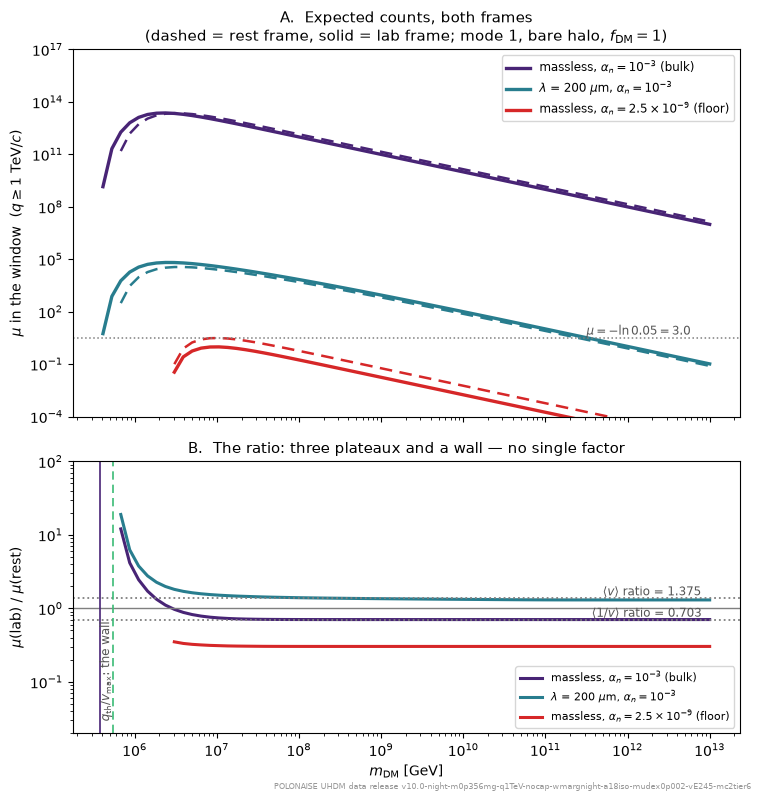

In [16]:
fig, (axA, axB) = plt.subplots(2, 1, figsize=(7.6, 8.0), sharex=True,
                               height_ratios=[1.35, 1])

for (label, xs, a_n, c) in CASES:
    m_rest, m_lab = MU[label]
    axA.loglog(MS, np.where(m_rest > 0, m_rest, np.nan), color=c, lw=1.8,
               ls=(0, (5, 3)))
    axA.loglog(MS, np.where(m_lab > 0, m_lab, np.nan), color=c, lw=2.4,
               label=label)
    ok = (m_rest > 0) & (m_lab > 0)
    axB.loglog(MS[ok], m_lab[ok] / m_rest[ok], color=c, lw=2.2, label=label)

axA.axhline(-np.log(0.05), color="#7f7f7f", lw=1.1, ls=":")
axA.text(6e12, -np.log(0.05) * 1.6, r"$\mu = -\ln 0.05 = 3.0$", fontsize=8.5,
         color="#555555", ha="right")
axA.set_ylim(1e-4, 1e17)
axA.set_ylabel(r"$\mu$ in the window  ($q \geq 1$ TeV/$c$)")
axA.set_title("A.  Expected counts, both frames\n"
              "(dashed = rest frame, solid = lab frame; mode 1, bare halo, "
              r"$f_{\rm DM} = 1$)", fontsize=11)
axA.legend(fontsize=8.5, loc="upper right")

for lvl, txt in ((R_INV, rf"$\langle 1/v\rangle$ ratio = {R_INV:.3f}"),
                 (R_VMEAN, rf"$\langle v\rangle$ ratio = {R_VMEAN:.3f}")):
    axB.axhline(lvl, color="#7f7f7f", lw=1.3, ls=":")
    axB.text(8e12, lvl * 1.09, txt, fontsize=8.5, color="#555555", ha="right")
axB.axhline(1.0, color="#7f7f7f", lw=1.0)
for v_max, c, ls, lab in ((V_MAX_REST, C_REST, (0, (5, 3)), "rest"),
                          (V_MAX_LAB, C_LAB, "-", "lab")):
    axB.axvline(Q_THRESH / v_max, color=c, lw=1.2, ls=ls)
axB.text(Q_THRESH / V_MAX_LAB, 0.03,
         r" $q_{\rm th}/v_{\rm max}$: the wall", fontsize=8.5, color="#555555",
         rotation=90, ha="left", va="bottom",
         transform=axB.get_xaxis_transform())
axB.set_ylim(2e-2, 1e2)
axB.set_xlabel(r"$m_{\rm DM}$ [GeV]")
axB.set_ylabel(r"$\mu$(lab) / $\mu$(rest)")
axB.set_title("B.  The ratio: three plateaux and a wall — no single factor",
              fontsize=11)
axB.legend(fontsize=8, loc="lower right")

fig.tight_layout()
save_figure(fig, "06_mu_vs_mass_two_frames")
plt.show()

<a id="7"></a>
## 7. The kinematic wall — and why the exclusion edge will not move by 1.45

The analysis window opens at $q_\text{th}$ = 1 TeV/$c$, and no halo particle can
deliver more than $q = m_\text{DM} v_\text{max}$. So there is a hard mass below
which the search is blind no matter how strong the coupling:

$$m_\text{wall} \;=\; \frac{q_\text{th}}{v_\text{max}} , \qquad
v_\text{max} = v_\text{esc} \;\to\; v_\text{esc} + v_E .$$

This is `config.Q_THRESH / config.V_MAX`, and it is the sharpest single
consequence of the frame change: 5.51 × 10⁵ → 3.80 × 10⁵ GeV, a factor 1.45 in
mass.

**But the wall is not the exclusion edge, and it should not be advertised as
one.** Two independent reasons, both quantified below:

1. **The tail there is sparse by construction.** At a mass just above the wall,
   the window is fed only by $v \ge q_\text{th}/m_\text{DM}$, which sits at the
   very top of a distribution that goes to zero *linearly* at
   $v_\text{esc}+v_E$. At $m_\text{DM} = 5\times10^5$ GeV the lab frame has only
   a few per cent of its flux available, and the rest frame has none.
2. **Near the coupling floor the wall is not even the binding edge.** Reaching
   $q_\text{th}$ at all needs $b_\text{max} > R_\text{eff}$, i.e.
   $v < v_* = 2\alpha/(q_\text{th}R_\text{eff})$, while the wall needs
   $v > q_\text{th}/m_\text{DM}$. Both can only hold if

   $$m_\text{DM} \;>\; m_\text{reach}(\alpha) \;=\; \frac{q_\text{th}^2 R_\text{eff}}{2\alpha},$$

   an edge with **no $v_\text{max}$ in it at all** — it does not move with the
   frame. Below a crossover coupling $\alpha_n^\times$ (computed below) it is
   $m_\text{reach}$, not $m_\text{wall}$, that closes the region on the left, and
   the v9.1 massless coupling floor sits below that crossover.

The honest statement for the paper: *the kinematic wall moves down by 1.45; the
low-mass edge of the excluded region moves by considerably less, because at the
couplings where that edge lives the binding constraint is the sensor-radius reach
and the available flux is a per-cent-level tail.* Where the two frames cross over
in rate is a rate question, not a kinematic one.

In [17]:
M_WALL_REST = Q_THRESH / V_MAX_REST
M_WALL_LAB = Q_THRESH / V_MAX_LAB
print(f"m_wall = q_th / v_max : {M_WALL_REST:.3e} -> {M_WALL_LAB:.3e} GeV "
      f"(x{M_WALL_REST / M_WALL_LAB:.4f})")
assert abs(M_WALL_REST / 5.51e5 - 1) < 3e-3, "the rest-frame wall moved"
assert abs(M_WALL_LAB / 3.80e5 - 1) < 3e-3, "the lab-frame wall moved"

# how sparse the relevant tail is: at a mass m the window is fed only by
# v >= q_th/m, so the usable flux fraction is the flux above that speed
def flux_above(v_cut, f, v):
    m = v >= v_cut
    return float(np.trapezoid((f * v)[m], v[m]) / np.trapezoid(f * v, v))


print(f"\n{'m_DM [GeV]':>12}{'v_min = q_th/m':>17}{'usable flux, rest':>19}"
      f"{'usable flux, lab':>18}")
for m_g in (4.0e5, 5.0e5, 6.0e5, 8.0e5, 1.2e6, 2.0e6, 5.0e6):
    v_min = Q_THRESH / m_g
    print(f"{m_g:>12.2e}{v_min * KMS:>14.0f} km/s"
          f"{flux_above(v_min, F_REST, V):>19.2e}"
          f"{flux_above(v_min, F_LAB, V):>18.2e}")

# the OTHER left-hand edge: the sensor-radius reach condition, which has no
# v_max in it and therefore does not move with the frame
R_EFF_GEV = units.conv_m2pGeV(R_eff)


def m_reach(alpha_n):
    """Lightest mass that can put q_th inside the window at this coupling."""
    return Q_THRESH ** 2 * R_EFF_GEV / (2 * alpha_n * config.N_NEUTRONS)


ALPHA_CROSS_REST = Q_THRESH * V_MAX_REST * R_EFF_GEV / (2 * config.N_NEUTRONS)
ALPHA_CROSS_LAB = Q_THRESH * V_MAX_LAB * R_EFF_GEV / (2 * config.N_NEUTRONS)
print(f"\nm_reach(alpha) = q_th^2 R_eff / (2 alpha): "
      f"{m_reach(A_BULK):.3e} GeV at alpha_n = {A_BULK:g}, "
      f"{m_reach(A_FLOOR):.3e} GeV at alpha_n = {A_FLOOR:g}")
print(f"the wall binds only above alpha_n_cross = {ALPHA_CROSS_REST:.3e} "
      f"(rest) / {ALPHA_CROSS_LAB:.3e} (lab);")
print(f"the v9.1 massless coupling floor is ~2.55e-9, i.e. BELOW it: there the "
      f"left-hand edge\nis m_reach, which carries no v_max and does not move "
      f"with the frame at all.")
assert m_reach(A_FLOOR) > M_WALL_REST, \
    "at the floor coupling the reach edge should sit above the kinematic wall"
assert m_reach(A_BULK) < M_WALL_LAB, \
    "at bulk coupling the wall should be the binding left-hand edge"

# where the lab frame stops winning: the crossover of the mu curves
label0 = CASES[0][0]
m_rest, m_lab = MU[label0]
ok = (m_rest > 0) & (m_lab > 0)
ratio = m_lab[ok] / m_rest[ok]
ms_ok = MS[ok]
cross = np.flatnonzero((ratio[:-1] > 1) & (ratio[1:] <= 1))
M_CROSS = float(np.exp(np.interp(0.0, np.log(ratio[cross[0]:cross[0] + 2])[::-1],
                                 np.log(ms_ok[cross[0]:cross[0] + 2])[::-1])))
print(f"\nlab-frame mu exceeds rest-frame mu only below "
      f"m_DM = {M_CROSS:.3e} GeV\n"
      f"  -- i.e. over a factor {M_CROSS / M_WALL_LAB:.1f} in mass above the new "
      f"wall, and nowhere else.")
assert M_WALL_LAB < M_CROSS < 100 * M_WALL_LAB

m_wall = q_th / v_max : 5.511e+05 -> 3.800e+05 GeV (x1.4504)

  m_DM [GeV]   v_min = q_th/m  usable flux, rest  usable flux, lab
    4.00e+05           749 km/s           0.00e+00          9.32e-04
    5.00e+05           600 km/s           0.00e+00          5.07e-02
    6.00e+05           500 km/s           2.00e-02          1.89e-01
    8.00e+05           375 km/s           2.02e-01          5.25e-01
    1.20e+06           250 km/s           6.25e-01          8.59e-01


    2.00e+06           150 km/s           9.19e-01          9.78e-01
    5.00e+06            60 km/s           9.97e-01          9.99e-01

m_reach(alpha) = q_th^2 R_eff / (2 alpha): 6.181e+00 GeV at alpha_n = 0.001, 2.472e+06 GeV at alpha_n = 2.5e-09
the wall binds only above alpha_n_cross = 1.122e-08 (rest) / 1.627e-08 (lab);
the v9.1 massless coupling floor is ~2.55e-9, i.e. BELOW it: there the left-hand edge
is m_reach, which carries no v_max and does not move with the frame at all.

lab-frame mu exceeds rest-frame mu only below m_DM = 2.865e+06 GeV
  -- i.e. over a factor 7.5 in mass above the new wall, and nowhere else.


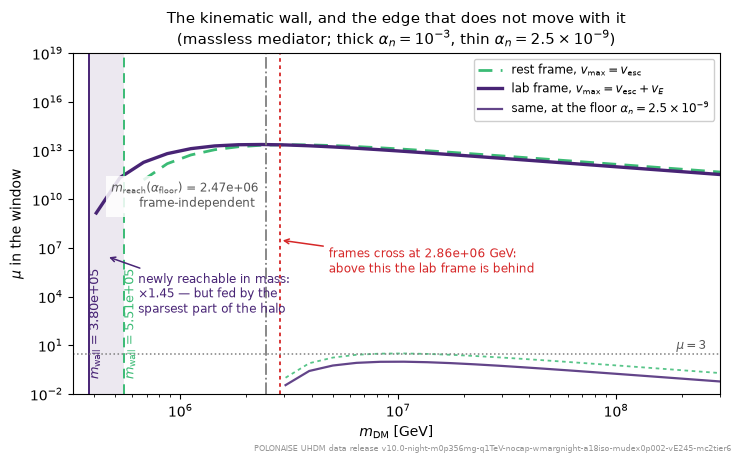

In [18]:
fig, ax = plt.subplots(figsize=(7.4, 4.6))

label0, label_fl = CASES[0][0], CASES[2][0]
m_rest, m_lab = MU[label0]
ax.loglog(MS, np.where(m_rest > 0, m_rest, np.nan), color=C_REST, lw=2.0,
          ls=(0, (5, 3)), label=r"rest frame, $v_{\rm max} = v_{\rm esc}$")
ax.loglog(MS, np.where(m_lab > 0, m_lab, np.nan), color=C_LAB, lw=2.4,
          label=r"lab frame, $v_{\rm max} = v_{\rm esc} + v_E$")

# the same pair at the coupling floor, where the exclusion edge actually lives:
# it starts nowhere near the wall, because m_reach binds first
f_rest, f_lab = MU[label_fl]
ax.loglog(MS, np.where(f_rest > 0, f_rest, np.nan), color=C_REST, lw=1.3,
          ls=(0, (2, 2)), alpha=0.85)
ax.loglog(MS, np.where(f_lab > 0, f_lab, np.nan), color=C_LAB, lw=1.6,
          alpha=0.85, label=r"same, at the floor $\alpha_n = 2.5\times10^{-9}$")
ax.axvline(m_reach(A_FLOOR), color="#7f7f7f", lw=1.3, ls="-.")
ax.text(m_reach(A_FLOOR) * 0.93, 0.58,
        rf"$m_{{\rm reach}}(\alpha_{{\rm floor}})$ = {m_reach(A_FLOOR):.2e}"
        "\nframe-independent ", color="#555555", fontsize=8.5,
        ha="right", va="center", transform=ax.get_xaxis_transform(),
        bbox=dict(fc="white", ec="none", alpha=0.85))

for m_w, c, ls, txt in ((M_WALL_REST, C_REST, (0, (5, 3)),
                         rf"$m_{{\rm wall}}$ = {M_WALL_REST:.2e}"),
                        (M_WALL_LAB, C_LAB, "-",
                         rf"$m_{{\rm wall}}$ = {M_WALL_LAB:.2e}")):
    ax.axvline(m_w, color=c, lw=1.4, ls=ls)
    ax.text(m_w, 0.02, "  " + txt, color=c, fontsize=9, rotation=90,
            ha="left", va="bottom", transform=ax.get_xaxis_transform())

ax.axvspan(M_WALL_LAB, M_WALL_REST, color=C_LAB, alpha=0.10, lw=0)
ax.annotate("newly reachable in mass:\n"
            rf"$\times${M_WALL_REST / M_WALL_LAB:.2f} — but fed by the"
            "\nsparsest part of the halo",
            xy=(np.sqrt(M_WALL_LAB * M_WALL_REST), 3e6), xytext=(6.4e5, 1e3),
            fontsize=8.5, color=C_LAB, ha="left",
            arrowprops=dict(arrowstyle="->", color=C_LAB, lw=1.1))
ax.axvline(M_CROSS, color=C_EDGE, lw=1.3, ls=(0, (2, 2)))
ax.annotate(f"frames cross at {M_CROSS:.2e} GeV:\n"
            "above this the lab frame is behind",
            xy=(M_CROSS, 3e7), xytext=(4.8e6, 3e5), fontsize=8.5,
            color=C_EDGE, ha="left",
            arrowprops=dict(arrowstyle="->", color=C_EDGE, lw=1.1))
ax.axhline(-np.log(0.05), color="#7f7f7f", lw=1.1, ls=":")
ax.text(2.6e8, -np.log(0.05) * 1.9, r"$\mu = 3$", fontsize=8.5,
        color="#555555", ha="right")

ax.set_xlim(3.2e5, 3e8)
ax.set_ylim(1e-2, 1e19)
ax.set_xlabel(r"$m_{\rm DM}$ [GeV]")
ax.set_ylabel(r"$\mu$ in the window")
ax.set_title("The kinematic wall, and the edge that does not move with it\n"
             r"(massless mediator; thick $\alpha_n = 10^{-3}$, "
             r"thin $\alpha_n = 2.5\times10^{-9}$)", fontsize=11)
ax.legend(fontsize=8.5, loc="upper right", framealpha=0.95)
fig.tight_layout()
save_figure(fig, "06_kinematic_wall")
plt.show()

<a id="8"></a>
## 8. Summary

One convention change, two moments, three consequences that do not share a sign.
The table below is assembled from the variables computed above — nothing in it is
typed in.

The one-paragraph version for a co-author: *adopting the lab-frame halo speeds
the arriving dark matter up by 37% on average. That pushes the flux-cut mass edge
$m_\text{cut}$ out by the same factor, extends the kinematically reachable mass
range downward by 45%, and raises the rates of finite-range mediators, whose
reach is a near-fixed aperture. At the same time it removes 30% of the slow
particles a Coulomb threshold kick needs, so the massless slice loses about a
third of its expected counts — and rather more than that near the coupling floor,
where the analysis window is fed by the slow tail alone. Massless and
finite-range results therefore move in opposite directions, and the low-mass edge
will not simply follow the 1.45 the kinematic wall moves by.*

In [19]:
print(f"{'quantity':<44}{'rest frame':>15}{'lab frame':>15}{'lab/rest':>11}")
print("-" * 85)
ROWS = [
    ("v_max = v_esc (+ v_E)  [km/s]", V_MAX_REST * KMS, V_MAX_LAB * KMS),
    ("<v>  [km/s]", V_MEAN_REST * KMS, V_MEAN_LAB * KMS),
    ("<1/v>  [s/km, x1e3]", INV_REST / KMS * 1e3, INV_LAB / KMS * 1e3),
    ("m_cut (f_DM = 1, N_req = 3)  [GeV]", M_CUT_REST_F1, M_CUT_LAB_F1),
    ("m_wall = q_th / v_max  [GeV]", M_WALL_REST, M_WALL_LAB),
    ("N_t, massless (shards)", 1.0, MED["massless"]),
    (r"N_t, 20 um (shards)", 1.0, MED[r"$\lambda$ = 20 $\mu$m"]),
    ("dR/dq, massless bulk, 3 TeV", 1.0, RATIO_BULK),
    ("dR/dq, 200 um bulk, 3 TeV", 1.0, RATIO_200),
    ("mu, massless bulk, m = 1.5e8 GeV", 1.0, QUOTED[(1.5e8, "bulk")]),
    ("mu, massless floor, m = 7.1e6 GeV", 1.0, QUOTED[(7.1e6, "floor")]),
]
for name, a, b in ROWS:
    fmt = "{:>15.4g}"
    print(f"{name:<44}" + fmt.format(a) + fmt.format(b) + f"{b / a:>11.4f}")

print("\nSign map (everything is bracketed by the same two moments):")
print("  UP   (-> x%.3f = <v>):    m_cut; transit counts and dR/dq through a "
      "near-fixed\n%15saperture, i.e. FINITE-RANGE mediators." % (R_VMEAN, ""))
print("  DOWN (-> x%.3f = <1/v>): Coulomb transit counts, MASSLESS dR/dq in "
      "the bulk,\n%15sand massless mu at heavy mass." % (R_INV, ""))
print("  DOWN (x%.3f):            m_wall -- reachable mass extends downward "
      "by x%.2f." % (M_WALL_LAB / M_WALL_REST, M_WALL_REST / M_WALL_LAB))
print("  Strongly DOWN (x%.2f):    near the coupling floor, where the window "
      "is fed only by\n%15sthe slow tail the boost removes." % (RATIO_FLOOR, ""))
print("  UNCHANGED:               m_reach = q_th^2 R_eff / 2 alpha, the "
      "left-hand edge that\n%15sbinds at the deepest couplings." % "")

rel.close()
print("\nrelease file closed")

quantity                                         rest frame      lab frame   lab/rest
-------------------------------------------------------------------------------------
v_max = v_esc (+ v_E)  [km/s]                           544            789     1.4504
<v>  [km/s]                                             246          338.2     1.3748
<1/v>  [s/km, x1e3]                                   5.152          3.624     0.7034
m_cut (f_DM = 1, N_req = 3)  [GeV]                6.111e+14      8.401e+14     1.3748
m_wall = q_th / v_max  [GeV]                      5.511e+05        3.8e+05     0.6895
N_t, massless (shards)                                    1         0.7041     0.7041
N_t, 20 um (shards)                                       1          1.334     1.3335
dR/dq, massless bulk, 3 TeV                               1         0.7042     0.7042
dR/dq, 200 um bulk, 3 TeV                                 1          1.332     1.3320
mu, massless bulk, m = 1.5e8 GeV                      